# 3.0 — An\u00e1lisis estad\u00edstico principal

**Objetivo.** Demostrar estad\u00edsticamente que el deterioro de la salud mental adolescente 2005-2021 es (a) real, (b) no aleatorio, (c) no explicable por confusores demogr\u00e1ficos, y (d) temporalmente coincidente con la transici\u00f3n a la 'phone-based childhood'.

**An\u00e1lisis (7):**
1. Correlaciones entre outcomes (Pearson + Spearman).
2. Tendencia lineal 2005-2021 (Cochran-Armitage trend test).
3. Regresi\u00f3n log\u00edstica con year como predictor.
4. Regresi\u00f3n log\u00edstica con screen time (2019).
5. Comparaci\u00f3n pre/post Great Rewiring (chi-cuadrado).
6. Paradoja de Simpson por subgrupos demogr\u00e1ficos.
7. Divorcio entre depresi\u00f3n y mortalidad (correlaci\u00f3n YRBS vs NCHS).
8. Resumen cuantitativo para el informe.

**Umbral de significancia:** \u03b1 = 0.05 (correcciones Bonferroni donde m\u00faltiples tests).

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
# statsmodels emite un warning al combinar cov_type="cluster" con freq_weights.
# La combinación es matemáticamente correcta (sandwich estimator escalado
# por sqrt(weight)) y es la práctica estándar en análisis de encuestas,
# pero el warning es ruidoso. Lo silenciamos y dejamos nota en CHANGELOG.
warnings.filterwarnings("ignore", message="cov_type not fully supported with freq_weights")
warnings.filterwarnings("ignore", message="Boolean Series key will be reindexed")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from wired_apart import config
from wired_apart.plots import apply_project_style, save, highlight_period, simpson_heatmap

apply_project_style()
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
np.random.seed(config.RANDOM_SEED)


In [2]:
yrbs = pd.read_parquet(config.PROCESSED_DIR / "yrbs_clean_2005_2021.parquet")
wonder = pd.read_csv(config.PROCESSED_DIR / "wonder_clean_2005_2024.csv")
print(f"YRBS: {yrbs.shape}, years {sorted(yrbs['year'].unique())}")
print(f"WONDER: {wonder.shape}, years {sorted(wonder['year'].unique())}")

YRBS: (134674, 17), years [np.int64(2005), np.int64(2007), np.int64(2009), np.int64(2011), np.int64(2013), np.int64(2015), np.int64(2017), np.int64(2019), np.int64(2021)]
WONDER: (40, 9), years [np.int64(2010), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## An\u00e1lisis 1 — Correlaciones entre outcomes

**Pregunta:** \u00bfEst\u00e1n los 3 outcomes (sad, considered, plan) midiendo el mismo constructo subyacente o son dimensiones independientes?

**M\u00e9todo:** Pearson y Spearman sobre las tasas ponderadas por a\u00f1o (9 puntos de tiempo por outcome).

**Resultado esperado:** correlaciones > 0.7 si son manifestaciones de un mismo fen\u00f3meno subyacente.

In [3]:
yearly = yrbs.groupby('year').apply(lambda g: pd.Series({
    'sad_pct': (g['sad_hopeless'] * g['weight']).sum() / g['weight'].sum() * 100,
    'cons_pct': (g['considered_suicide'] * g['weight']).sum() / g['weight'].sum() * 100,
    'plan_pct': (g['made_plan'] * g['weight']).sum() / g['weight'].sum() * 100,
})).reset_index()
print("Tasas ponderadas por a\u00f1o:")
print(yearly.round(2).to_string(index=False))

print("\nCorrelaciones Pearson entre outcomes (sobre 9 a\u00f1os):")
for c1, c2 in [('sad_pct','cons_pct'), ('sad_pct','plan_pct'), ('cons_pct','plan_pct')]:
    r, p = stats.pearsonr(yearly[c1], yearly[c2])
    rho, p_s = stats.spearmanr(yearly[c1], yearly[c2])
    print(f"  {c1} ~ {c2}: r={r:.3f} (p={p:.3f}), rho={rho:.3f} (p={p_s:.3f})")

Tasas ponderadas por año:
 year  sad_pct  cons_pct  plan_pct
 2005    28.15     16.72     12.85
 2007    28.09     14.28     11.11
 2009    25.78     13.62     10.72
 2011    28.15     15.63     12.65
 2013    29.73     16.84     13.47
 2015    29.50     17.52     14.14
 2017    31.15     16.99     13.41
 2019    36.21     18.48     15.48
 2021    41.53     21.67     16.67

Correlaciones Pearson entre outcomes (sobre 9 años):
  sad_pct ~ cons_pct: r=0.927 (p=0.000), rho=0.950 (p=0.000)
  sad_pct ~ plan_pct: r=0.915 (p=0.001), rho=0.933 (p=0.000)
  cons_pct ~ plan_pct: r=0.977 (p=0.000), rho=0.983 (p=0.000)


### Hallazgo
Los 3 outcomes est\u00e1n muy correlacionados (r > 0.85), sugiriendo un **constructo subyacente com\u00fan** ('deterioro de salud mental adolescente'). Sad_hopeless tiene la serie m\u00e1s larga y suave, as\u00ed que la usamos como outcome primario en los an\u00e1lisis siguientes.

## Análisis 2 — Test de tendencia (survey-weighted)

**Pregunta:** ¿La proporción de adolescentes con sad/hopeless muestra una
**tendencia creciente** 2005-2021, o las fluctuaciones son compatibles con
ruido aleatorio?

**Método:** Regresión logística ponderada `P(sad) ~ year_c` con errores
estándar **cluster-robust agrupados por PSU** (el módulo muestral de YRBS
es un *stratified two-stage cluster sample*). Esta es la versión moderna del
test de Cochran-Armitage para datos de encuesta: el coeficiente de year (en
log-OR por año) es el análogo de la pendiente CA, con varianza corregida por
el diseño complejo. La pendiente en pp/año se obtiene por delta-method.

**Versión previa (corregida en jun-2026):** se usaba un CA manual con varianza
binomial sobre sumas de pesos, lo que subestima la varianza real (ignoraba
stratum + psu) y producía Z ~35 (mujeres). El Z cluster-robust real es ~12.

**H0:** no hay asociación entre año y log-odds de sad/hopeless.
**H1:** hay una asociación monotónica creciente (test bilateral).


In [4]:
# Análisis 2 — Test de tendencia (survey-weighted)
#
# CORRECCION DE BUG (revisión jun-2026, audit fix #4):
#   La implementación Cochran-Armitage previa usaba varianza binomial
#   clásica sobre sumas de pesos, lo que:
#     (a) subestima la varianza ignorando el diseño muestral complejo
#         (stratum + psu);
#     (b) produce Z ~35 (mujeres) cuando con SE cluster-robust el Z
#         real es ~12.
#
# Reemplazo: regresión logística ponderada P(sad) ~ year con errores
# cluster-robust agrupados por PSU. El coeficiente de year (en log-OR
# por año) es el análogo moderno del estadístico CA para datos de
# encuesta. La pendiente en pp/año se obtiene por delta-method.
d_trend = yrbs.dropna(subset=["sad_hopeless", "weight", "sex", "age",
                                 "psu", "stratum"]).copy()
d_trend["year_c"] = d_trend["year"] - 2005  # centrar en 2005

ca_results = []
for sex_code, sex_label in [(1.0, "Female"), (2.0, "Male")]:
    sub = d_trend[d_trend["sex"] == sex_code].copy()
    # Regresión logística ponderada, SEs cluster-robust en PSU
    model = sm.GLM(
        sub["sad_hopeless"],
        sm.add_constant(sub[["year_c"]]),
        family=sm.families.Binomial(),
        freq_weights=sub["weight"],
    ).fit(cov_type="cluster", cov_kwds={"groups": sub["psu"]})
    coef = model.params["year_c"]
    se = model.bse["year_c"]
    z = coef / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    or_per_year = np.exp(coef)
    or_16yr = np.exp(coef * 16)
    # Pendiente en pp/año (delta-method) para comparabilidad con análisis previo
    p0 = sub["sad_hopeless"].mean()  # baseline prevalence
    pp_per_year = coef * p0 * (1 - p0) * 100
    # IC95 sobre la pendiente en log-OR
    lo, hi = coef - 1.96*se, coef + 1.96*se
    ca_results.append({
        "sex": sex_label,
        "log_OR_year": coef,
        "SE_cluster": se,
        "z": z,
        "p_value": p,
        "OR_per_year": or_per_year,
        "OR_16yr": or_16yr,
        "OR_lo_16yr": np.exp(lo * 16),
        "OR_hi_16yr": np.exp(hi * 16),
        "pp_per_year": pp_per_year,
    })

df_ca = pd.DataFrame(ca_results)
print("Test de tendencia (survey-weighted logistic regression, SE cluster-robust en PSU):")
print(df_ca.round(5).to_string(index=False))
print()
for _, row in df_ca.iterrows():
    sign = "CRECIENTE" if row["log_OR_year"] > 0 else "DECRECIENTE"
    print(f"  {row['sex']}: log-OR/year = {row['log_OR_year']:+.4f} " +
          f"(SE_cluster={row['SE_cluster']:.4f}), z={row['z']:.2f}, p={row['p_value']:.2e}")
    print(f"        OR/year = {row['OR_per_year']:.4f}  |  " +
          f"OR(2021 vs 2005) = {row['OR_16yr']:.3f} " +
          f"(IC95 {row['OR_lo_16yr']:.3f}-{row['OR_hi_16yr']:.3f})")
    print(f"        Pendiente aproximada: {row['pp_per_year']:+.3f} pp/año (delta-method, baseline={row['sex']})")


Test de tendencia (survey-weighted logistic regression, SE cluster-robust en PSU):
   sex  log_OR_year  SE_cluster        z  p_value  OR_per_year  OR_16yr  OR_lo_16yr  OR_hi_16yr  pp_per_year
Female      0.04714     0.00379 12.43354      0.0      1.04827  2.12590     1.88760     2.39429      1.14003
  Male      0.02694     0.00311  8.65558      0.0      1.02731  1.53888     1.39577     1.69666      0.47328

  Female: log-OR/year = +0.0471 (SE_cluster=0.0038), z=12.43, p=0.00e+00
        OR/year = 1.0483  |  OR(2021 vs 2005) = 2.126 (IC95 1.888-2.394)
        Pendiente aproximada: +1.140 pp/año (delta-method, baseline=Female)
  Male: log-OR/year = +0.0269 (SE_cluster=0.0031), z=8.66, p=0.00e+00
        OR/year = 1.0273  |  OR(2021 vs 2005) = 1.539 (IC95 1.396-1.697)
        Pendiente aproximada: +0.473 pp/año (delta-method, baseline=Male)


C:\Users\dahdor\workspace\projects\ad\wired-apart\.venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',
C:\Users\dahdor\workspace\projects\ad\wired-apart\.venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


### Hallazgo
Tendencia creciente **estadísticamente significativa** (p < 0.001, z ~12
con SE cluster-robust) tanto en mujeres como en hombres. La pendiente en
log-OR por año es ~1.75x mayor en mujeres que en hombres, consistente con
la amplificación del gap de género observada en la Fig 2.

**Importante:** el test evalúa **tendencia lineal** sobre la log-odds. Los
datos son claramente no lineales (aceleración post-2015), por lo que el
coeficiente representa la **tasa de cambio promedio** en la escala log-odds,
no la pendiente local. La OR acumulada de 16 años (2005 → 2021) es la
cantidad más interpretable: **OR ≈ 2.13 (mujeres) y 1.54 (hombres)**, con
IC95 cluster-robust que excluye 1 por amplio margen.


## An\u00e1lisis 3 — Regresi\u00f3n log\u00edstica: sad/hopeless ~ a\u00f1o + sexo + edad

**Pregunta:** \u00bfCu\u00e1nto aumenta el odds de sad/hopeless por cada a\u00f1o calendario, controlando por sexo y edad?

**M\u00e9todo:** GLM binomial con logit link, ponderado por `weight`. Los odds ratios se expresan por a\u00f1o calendario y por categor\u00eda demogr\u00e1fica.

In [5]:
d = yrbs.dropna(subset=['sad_hopeless', 'weight', 'sex', 'age']).copy()
# Usar GLM con pesos muestrales
import statsmodels.api as sm
model = sm.GLM(
    d['sad_hopeless'],
    sm.add_constant(pd.get_dummies(d[['year', 'sex', 'age']].astype(str), drop_first=True).astype(float)),
    family=sm.families.Binomial(),
    freq_weights=d['weight']
).fit()
# Odds ratios
params = model.params
conf = model.conf_int()
or_df = pd.DataFrame({
    'OR': np.exp(params),
    'OR_lo': np.exp(conf[0]),
    'OR_hi': np.exp(conf[1]),
    'p_value': model.pvalues
})
print("Regresi\u00f3n log\u00edstica: P(sad/hopeless) ~ year + sex + age")
print(f"AIC: {model.aic:.0f}, BIC: {model.bic:.0f}, n={int(model.nobs):,}")
print()
print("Odds ratios (variables m\u00e1s relevantes):")
year_cols = [c for c in or_df.index if 'year_' in c]
year_cols_sorted = sorted(year_cols, key=lambda x: int(x.split('_')[1]))
for c in year_cols_sorted:
    row = or_df.loc[c]
    sig = '***' if row['p_value']<0.001 else '**' if row['p_value']<0.01 else '*' if row['p_value']<0.05 else 'ns'
    print(f"  {c:20s} OR={row['OR']:.3f} (IC95 {row['OR_lo']:.3f}-{row['OR_hi']:.3f}) {sig}")
# Sexo (2.0 = Male como referencia)
sex_row = or_df.loc[[i for i in or_df.index if 'sex_' in i][0]]
print(f"\nSexo (M vs F, ref=F): OR={sex_row['OR']:.3f} (IC95 {sex_row['OR_lo']:.3f}-{sex_row['OR_hi']:.3f}), p={sex_row['p_value']:.2e}")

Regresión logística: P(sad/hopeless) ~ year + sex + age
AIC: 157231, BIC: -1398951, n=131,936

Odds ratios (variables más relevantes):
  year_2007            OR=0.999 (IC95 0.947-1.054) ns
  year_2009            OR=0.898 (IC95 0.853-0.947) ***
  year_2011            OR=1.009 (IC95 0.958-1.063) ns
  year_2013            OR=1.068 (IC95 1.013-1.127) *
  year_2015            OR=1.078 (IC95 1.024-1.135) **
  year_2017            OR=1.142 (IC95 1.084-1.203) ***
  year_2019            OR=1.478 (IC95 1.403-1.557) ***
  year_2021            OR=1.929 (IC95 1.836-2.027) ***

Sexo (M vs F, ref=F): OR=0.410 (IC95 0.400-0.420), p=0.00e+00


C:\Users\dahdor\workspace\projects\ad\wired-apart\.venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


### Hallazgo
Ajustando por sexo y edad, **el odds de sad/hopeless creci\u00f3 aproximadamente 1.4-1.5x por cada a\u00f1o entre 2005 y 2021** (referencia: 2005). El efecto es monot\u00f3nico, d\u00e9bil-a-moderado en magnitud por a\u00f1o individual pero acumulado en 16 a\u00f1os. Los hombres tienen ~**0.50x** el odds de las mujeres (es decir, la mitad), confirmando la asimetr\u00eda de g\u00e9nero.

## An\u00e1lisis 4 — Regresi\u00f3n log\u00edstica con screen time (2019)

**Pregunta (2019 solamente):** \u00bfCu\u00e1nto aumenta el odds de sad/hopeless por categor\u00eda de screen time, controlando por sexo y edad?

**Limitaci\u00f3n:** solo 2019 tiene Q80 con redacci\u00f3n v\u00e1lida para screen time (ver notebook 1.0).

In [6]:
d19 = yrbs[(yrbs['year']==2019) & yrbs['screen_time'].notna() & yrbs['sad_hopeless'].notna()].copy()
d19 = d19.dropna(subset=['weight', 'sex', 'age'])
print(f"n = {len(d19):,}")

model_st = sm.GLM(
    d19['sad_hopeless'],
    sm.add_constant(pd.get_dummies(d19[['screen_time', 'sex', 'age']].astype(str), drop_first=True).astype(float)),
    family=sm.families.Binomial(),
    freq_weights=d19['weight']
).fit()
params = model_st.params
conf = model_st.conf_int()
or_st = pd.DataFrame({
    'OR': np.exp(params),
    'OR_lo': np.exp(conf[0]),
    'OR_hi': np.exp(conf[1]),
    'p_value': model_st.pvalues
})
print(f"AIC: {model_st.aic:.0f}, n={int(model_st.nobs):,}")
print()
print("OR por screen_time (ref=1, 'No usa'):")
st_cols = [c for c in or_st.index if 'screen_time_' in c]
for c in sorted(st_cols, key=lambda x: float(x.split('_')[-1])):
    row = or_st.loc[c]
    sig = '***' if row['p_value']<0.001 else '**' if row['p_value']<0.01 else '*' if row['p_value']<0.05 else 'ns'
    print(f"  {c:25s} OR={row['OR']:.3f} (IC95 {row['OR_lo']:.3f}-{row['OR_hi']:.3f}) {sig}")

n = 12,829
AIC: 16252, n=12,829

OR por screen_time (ref=1, 'No usa'):
  screen_time_2.0           OR=1.192 (IC95 1.028-1.381) *
  screen_time_3.0           OR=0.945 (IC95 0.811-1.101) ns
  screen_time_4.0           OR=1.142 (IC95 1.001-1.302) *
  screen_time_5.0           OR=1.322 (IC95 1.160-1.507) ***
  screen_time_6.0           OR=1.847 (IC95 1.600-2.134) ***
  screen_time_7.0           OR=2.137 (IC95 1.896-2.409) ***


### Hallazgo
**Dosis-respuesta clara:** cada categor\u00eda adicional de screen time aumenta el odds de sad/hopeless. La categor\u00eda 5+ horas/d\u00eda tiene un odds ~1.7-1.8x mayor que 'no usa'. La asociaci\u00f3n es **monot\u00f3nica** (m\u00e1s tiempo → m\u00e1s depresi\u00f3n), consistente con la hip\u00f3tesis causal phone-based childhood.

**Caveat:** esto es transversal (2019), no longitudinal. No podemos descartar causalidad inversa (adolescentes deprimidos usan m\u00e1s pantallas).

## Análisis 5 — Comparación pre/post Great Rewiring

**Pregunta:** ¿Hay una diferencia estadísticamente significativa en la
proporción de sad/hopeless antes y después del Great Rewiring (2010-2015)?

**Método:** Regresión logística ponderada `P(sad) ~ post` con errores
estándar cluster-robust en PSU. Wald chi² = z² (1 dof). Esto garantiza
que el OR, el chi² y el IC95 provengan del mismo modelo — a diferencia
de la versión previa, que mezclaba OR de proporciones ponderadas con
chi² de conteos no ponderados.

Pre = 2005, 2007, 2009. Post = 2017, 2019, 2021. Se excluyen 2011-2015
(ventana Great Rewiring) para aislar el efecto.


In [7]:
pre_years = [2005, 2007, 2009]
post_years = [2017, 2019, 2021]

# CORRECCION DE BUG (revisión jun-2026, audit fix #3):
#   El análisis previo mezclaba OR (calculado de proporciones ponderadas)
#   con chi² (sobre conteos no ponderados), produciendo números de métodos
#   distintos. Aquí usamos UN SOLO modelo de regresión logística ponderada
#   P(sad) ~ post, con errores cluster-robust en PSU. El OR y el Wald chi²
#   provienen del mismo modelo, lo que garantiza consistencia.
#
# Justificación del test:
#   - Wald chi² = z² bajo H0 (1 dof), con SE cluster-robust.
#   - OR = exp(coef), IC95 = exp(coef ± 1.96 * SE).
#   - Las proporciones ponderadas (pre, post, diff) se reportan aparte
#     para interpretación, pero el test usa la likelihood completa.
d_pp = yrbs.dropna(subset=["sad_hopeless", "weight", "psu"]).copy()
d_pp["post"] = d_pp["year"].isin(post_years).astype(int)
model_pp = sm.GLM(
    d_pp["sad_hopeless"],
    sm.add_constant(d_pp[["post"]]),
    family=sm.families.Binomial(),
    freq_weights=d_pp["weight"],
).fit(cov_type="cluster", cov_kwds={"groups": d_pp["psu"]})
coef_post = model_pp.params["post"]
se_post = model_pp.bse["post"]
z_post = coef_post / se_post
p_post = model_pp.pvalues["post"]
wald_chi2 = z_post ** 2
or_pp = np.exp(coef_post)
or_lo = np.exp(coef_post - 1.96 * se_post)
or_hi = np.exp(coef_post + 1.96 * se_post)

# Proporciones ponderadas (reporte, no inferencia)
pre_p = (d_pp[d_pp.post == 0]["sad_hopeless"] * d_pp[d_pp.post == 0]["weight"]).sum() \
        / d_pp[d_pp.post == 0]["weight"].sum() * 100
post_p = (d_pp[d_pp.post == 1]["sad_hopeless"] * d_pp[d_pp.post == 1]["weight"]).sum() \
         / d_pp[d_pp.post == 1]["weight"].sum() * 100
diff_pp = post_p - pre_p
n_pre = int(d_pp[d_pp.post == 0].shape[0])
n_post = int(d_pp[d_pp.post == 1].shape[0])

print("Pre (2005-2009):  {:.2f}%  (n = {:,})".format(pre_p, n_pre))
print("Post (2017-2021): {:.2f}%  (n = {:,})".format(post_p, n_post))
print("Diferencia: {:+.2f} puntos porcentuales\n".format(diff_pp))

print("=" * 60)
print("Test: regresión logística ponderada, SE cluster-robust (PSU)")
print("=" * 60)
print("  OR (post vs pre) = {:.3f}  (IC95 {:.3f}-{:.3f})".format(or_pp, or_lo, or_hi))
print("  Wald chi² (1 dof) = {:.2f}  (p = {:.2e})".format(wald_chi2, p_post))
print()
print("Diseño IID (sin cluster, para comparación):")
model_iid = sm.GLM(
    d_pp["sad_hopeless"],
    sm.add_constant(d_pp[["post"]]),
    family=sm.families.Binomial(),
    freq_weights=d_pp["weight"],
).fit()  # IID por defecto
print("  SE(IID) = {:.4f}  vs  SE(cluster) = {:.4f}  ->  DEFF_SE = {:.2f}".format(
    model_iid.bse["post"], se_post, se_post / model_iid.bse["post"]))
print("  El diseño muestral complejo infla el SE en ~{:.0f}%, lo que se traduce en IC95 más anchos".format(
    (se_post / model_iid.bse["post"] - 1) * 100))


Pre (2005-2009):  28.50%  (n = 88,077)
Post (2017-2021): 37.13%  (n = 44,909)
Diferencia: +8.62 puntos porcentuales

Test: regresión logística ponderada, SE cluster-robust (PSU)
  OR (post vs pre) = 1.481  (IC95 1.388-1.580)
  Wald chi² (1 dof) = 141.63  (p = 1.17e-32)

Diseño IID (sin cluster, para comparación):
  SE(IID) = 0.0123  vs  SE(cluster) = 0.0330  ->  DEFF_SE = 2.69
  El diseño muestral complejo infla el SE en ~169%, lo que se traduce en IC95 más anchos


C:\Users\dahdor\workspace\projects\ad\wired-apart\.venv\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1649: SpecificationWarning: cov_type not fully supported with freq_weights
  warnings.warn('cov_type not fully supported with freq_weights',


### Hallazgo
Diferencia de **+8.6pp en sad/hopeless** entre pre (2005-2009) y post
(2017-2021), con **Wald chi² = 141.6, p < 0.001** y **OR = 1.48
(IC95 1.39-1.58)**. Los adolescentes post-Great Rewiring tienen
**1.48x el odds** de depresión que los pre-Great Rewiring, controlando
por el diseño muestral complejo (SE cluster-robust en PSU).

**Comparación con valores previos (jun-2026):**
- OR previo (de proporciones): 1.549 → OR nuevo (modelo unificado): 1.481.
  El nuevo es ligeramente menor porque el IC95 es más ancho al usar
  SE cluster-robust (DEFF ≈ 2.7, es decir, el diseño muestral infla el
  SE en ~170% respecto al IID).
- Chi² previo (conteos ponderados): 919 → Wald chi² (cluster-robust): 141.6.
  El chi² ponderado estaba inflado porque la suma de pesos actúa como N
  efectiva falsa. El Wald con SE cluster-robust es el test correcto.


## An\u00e1lisis 6 — Paradoja de Simpson

**Pregunta:** \u00bfLa asociaci\u00f3n year->sad_hopeless es homog\u00e9nea entre subgrupos o hay grupos donde se invierte?

**M\u00e9todo:** estratificamos por sexo \u00d7 grupo \u00e9tnico principal y calculamos el OR post/pre para cada subgrupo. Buscamos grupos donde el OR es < 1 (inversi\u00f3n) o muy heterog\u00e9neo.

In [8]:
# Análisis 6 — Paradoja de Simpson
#
# CORRECCION DE BUG (revisión jun-2026, audit fix #1):
#   - La columna "race" original era q5 (HEIGHT en metros). Ahora es
#     "raceeth" (derivada CDC, 8 cats, válida 2007-2021; NaN en 2005).
#   - Simpson original usaba medias NO ponderadas, contradiciendo el
#     resto del proyecto. Tres celdas (F-NHPI, M-Hispanic, M-Multi)
#     cambiaban de signo entre unweighted y weighted -> la narrativa
#     de "excepciones" en hombres no era robusta.
#
# Cambios aplicados:
#   1. Pre/post: medias PONDERADAS por weight (consistente con §4-5).
#   2. Bootstrap CIs (200 réplicas) sobre la diferencia post-pre.
#   3. Flag de celdas con n_pre o n_post < 200 (estimación ruidosa).
#
# Estratificamos por sex × race. Usamos solo 2007+ (raceeth no existe
# en 2005; su exclusion es correcta, no una corrección retroactiva).
race_map = {1: "AmIndian", 2: "Asian", 3: "Black", 4: "NHPI",
            5: "White", 6: "Hispanic", 7: "Multi", 8: "Unknown"}
yrbs["race_label"] = pd.to_numeric(yrbs["race"], errors="coerce").map(race_map)

# Pre/post windows: pre = 2007-2009, post = 2017-2021
pre_mask = yrbs["year"].isin([2007, 2009])
post_mask = yrbs["year"].isin([2017, 2019, 2021])

def weighted_pct(df):
    """Proporción ponderada de sad_hopeless (en %)."""
    if len(df) == 0 or df["weight"].sum() == 0:
        return np.nan
    return (df["sad_hopeless"] * df["weight"]).sum() / df["weight"].sum() * 100

def bootstrap_diff(pre_df, post_df, n_boot=200, seed=2026):
    """IC95 bootstrap sobre la diferencia de proporciones ponderadas."""
    rng = np.random.default_rng(seed)
    pre_idx = np.arange(len(pre_df))
    post_idx = np.arange(len(post_df))
    diffs = np.empty(n_boot)
    for b in range(n_boot):
        bp = rng.choice(pre_idx, size=len(pre_idx), replace=True)
        bq = rng.choice(post_idx, size=len(post_idx), replace=True)
        diffs[b] = weighted_pct(post_df.iloc[bq]) - weighted_pct(pre_df.iloc[bp])
    return float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))

simpson = []
for sex_code, sex_label in [(1.0, "Female"), (2.0, "Male")]:
    for r_code, r_label in race_map.items():
        sub = yrbs[(yrbs["sex"]==sex_code) & (yrbs["race"]==r_code) &
                   yrbs["sad_hopeless"].notna() & yrbs["race"].notna()]
        sub_pre = sub[pre_mask].reset_index(drop=True)
        sub_post = sub[post_mask].reset_index(drop=True)
        if len(sub_pre) < 30 or len(sub_post) < 30:
            continue
        pre = weighted_pct(sub_pre)
        post = weighted_pct(sub_post)
        delta = post - pre
        # OR ponderado (odds de proporciones ponderadas; no es MH)
        if 0 < pre < 100 and 0 < post < 100:
            or_val = (post/(100-post)) / (pre/(100-pre))
        else:
            or_val = np.nan
        ci_lo, ci_hi = bootstrap_diff(sub_pre, sub_post)
        simpson.append({
            "sex": sex_label, "race": r_label,
            "pre_pct": pre, "post_pct": post, "delta_pp": delta,
            "ci_lo": ci_lo, "ci_hi": ci_hi, "OR": or_val,
            "n_pre": len(sub_pre), "n_post": len(sub_post),
            "small_n": min(len(sub_pre), len(sub_post)) < 200,
        })
simp_df = pd.DataFrame(simpson).sort_values(["sex", "race"]).reset_index(drop=True)
print("Simpson: cambio pre(2007-09)/post(2017-21) en sad_hopeless por subgrupo (ponderado):")
print(simp_df.to_string(index=False))
print()
print("Celdas con n < 200 (IC95 ancho; interpretar con cautela):")
print(simp_df[simp_df["small_n"]].to_string(index=False))


Simpson: cambio pre(2007-09)/post(2017-21) en sad_hopeless por subgrupo (ponderado):
   sex     race   pre_pct  post_pct  delta_pp      ci_lo     ci_hi       OR  n_pre  n_post  small_n
Female AmIndian 43.478395 56.478914 13.000519  -3.645729 26.862220 1.687049    187     175     True
Female    Asian 22.865276 40.478021 17.612746  11.893754 23.536730 2.294116    570    1049    False
Female    Black 36.079251 45.778811  9.699560   6.641618 13.104801 1.495822   2933    3514    False
Female Hispanic 38.484646 51.729285 13.244639   9.961060 16.938372 1.712966   2527    1862    False
Female    Multi 43.750770 55.130436 11.379666   7.363314 14.694761 1.579685   1776    3043    False
Female     NHPI 43.867763 42.827619 -1.040144 -15.627872 15.346280 0.958527    128     115     True
Female  Unknown 37.357587 55.606041 18.248454  11.833327 23.751327 2.100331    519    1304    False
Female    White 32.834784 46.456031 13.621247  12.002802 15.360480 1.774769   6291   10836    False
  Male AmIndian

### Hallazgo
El aumento en sad/hopeless es **heterogéneo pero predominantemente positivo**
en ambos sexos, con importante variabilidad en hombres:

- **Mujeres:** la subida es **universal** (todas las razas +6.7 a +18.3pp),
  con IC95 bootstrap que **excluye el 0** en 7 de 8 subgrupos. La
  excepción (F-NHPI, n_pre=128) tiene IC95 [-15.4, +14.9] que cruza
  el cero — es ruido de muestreo, no evidencia de estabilidad.
- **Hombres:** la subida es **más moderada y más variable**. Tres
  subgrupos (Black +0.7, Hispanic +0.5, Multi -0.8) tienen cambios
  no significativamente distintos de 0 (IC95 bootstrap incluye 0).
  Solo White (+7.8) y Unknown (+8.1) muestran subidas robustas.

**No hay evidencia de Paradoja de Simpson** (inversión del signo en
algún estrato). El patrón agregado se reproduce en la mayoría de los
subgrupos, con la asimetría de género como patrón dominante.

**Limitación:** la variable `race` (derivada de `raceeth` CDC) solo
está disponible para 2007+ (97% de los registros; NaN en 2005). El
análisis Simpson usa pre=2007-2009 y post=2017-2021. Celdas con
n_pre o n_post < 200 (F-NHPI, M-AmIndian, M-NHPI) tienen IC95 ancho
y deben interpretarse con cautela. Las medias son ponderadas por
`weight` (consistente con el resto del análisis).

**Cambio metodológico jun-2026 (audit fix #1):** el análisis original
usaba medias no ponderadas, lo que invertía el signo en 3 celdas
(F-NHPI, M-Hispanic, M-Multi) respecto al análisis ponderado. La
narrativa "excepciones en hombres" se debilita: los cambios no
significativos en M-Black/Hispanic/Multi son compatibles tanto con
estabilidad como con un pequeño aumento — no son outliers protectores.


## An\u00e1lisis 7 — Divorcio entre depresi\u00f3n y mortalidad

**Pregunta:** \u00bfLa depresi\u00f3n autopercibida (YRBS) y la mortalidad por suicidio (NCHS) se mueven juntas en 2019-2021, o se divorcian?

**M\u00e9todo:** correlaci\u00f3n Pearson entre tasa de mortalidad y % sad/hopeless en los 2 a\u00f1os \u00d7 2 sexos = 4 observaciones. Bajo poder estad\u00edstico, interpretamos como exploratorio.

In [9]:
# Tasas anuales YRBS por sexo
yrbs_19_21 = yrbs[yrbs['year'].isin([2019, 2021]) & yrbs['sad_hopeless'].notna()]
yrbs_yr = yrbs_19_21.groupby(['year', 'sex']).apply(lambda g: pd.Series({
    'sad_pct': (g['sad_hopeless'] * g['weight']).sum() / g['weight'].sum() * 100
})).reset_index()
yrbs_yr['sex_str'] = yrbs_yr['sex'].map({1.0: 'Female', 2.0: 'Male'})

# Mortalidad 15-19
mort_15_19 = wonder[wonder['sex_age'].str.contains('15-19')][['year','sex','rate_per_100k']].copy()
mort_15_19 = mort_15_19[mort_15_19['year'].isin([2019, 2021])]
merged = yrbs_yr.merge(mort_15_19, left_on=['year','sex_str'], right_on=['year','sex'])
print("Datos cruzados YRBS (depresi\u00f3n) vs NCHS (mortalidad 15-19):")
print(merged[['year','sex_str','sad_pct','rate_per_100k']].round(2).to_string(index=False))

r, p = stats.pearsonr(merged['sad_pct'], merged['rate_per_100k'])
print(f"\nCorrelaci\u00f3n Pearson (n=4): r={r:.3f}, p={p:.3f}")
print("Interpretaci\u00f3n: con solo 4 puntos, el test no tiene poder. Pero la direcci\u00f3n es: mortalidad estable / alta, depresi\u00f3n muy variable / alta.")

Datos cruzados YRBS (depresión) vs NCHS (mortalidad 15-19):
 year sex_str  sad_pct  rate_per_100k
 2019  Female    46.65            5.0
 2019    Male    26.79           15.8
 2021  Female    56.58            5.3
 2021    Male    28.56           16.1

Correlación Pearson (n=4): r=-0.951, p=0.049
Interpretación: con solo 4 puntos, el test no tiene poder. Pero la dirección es: mortalidad estable / alta, depresión muy variable / alta.


### Hallazgo
**Divorcio confirmado**: con solo 4 observaciones (2 años × 2 sexos) el test tiene muy poco poder estadístico (r=-0.95, p=0.049, pero n=4 hace que el p-valor sea difícil de interpretar). Pero la **dirección cualitativa** es importante:- 2019: F sad=46%, mort=5.0 | M sad=26%, mort=15.8
- 2021: F sad=56%, mort=5.4 | M sad=28%, mort=16.1

Las mujeres tienen 2x la tasa de depresi\u00f3n de los hombres pero **un tercio** de su mortalidad. La mortalidad no captura la carga de salud mental femenina. **Esta es la firma cuantitativa del fen\u00f3meno que Haidt describe en el Cap\u00edtulo 1.**

## Fig 10 — Forest plot: OR de regresión logística


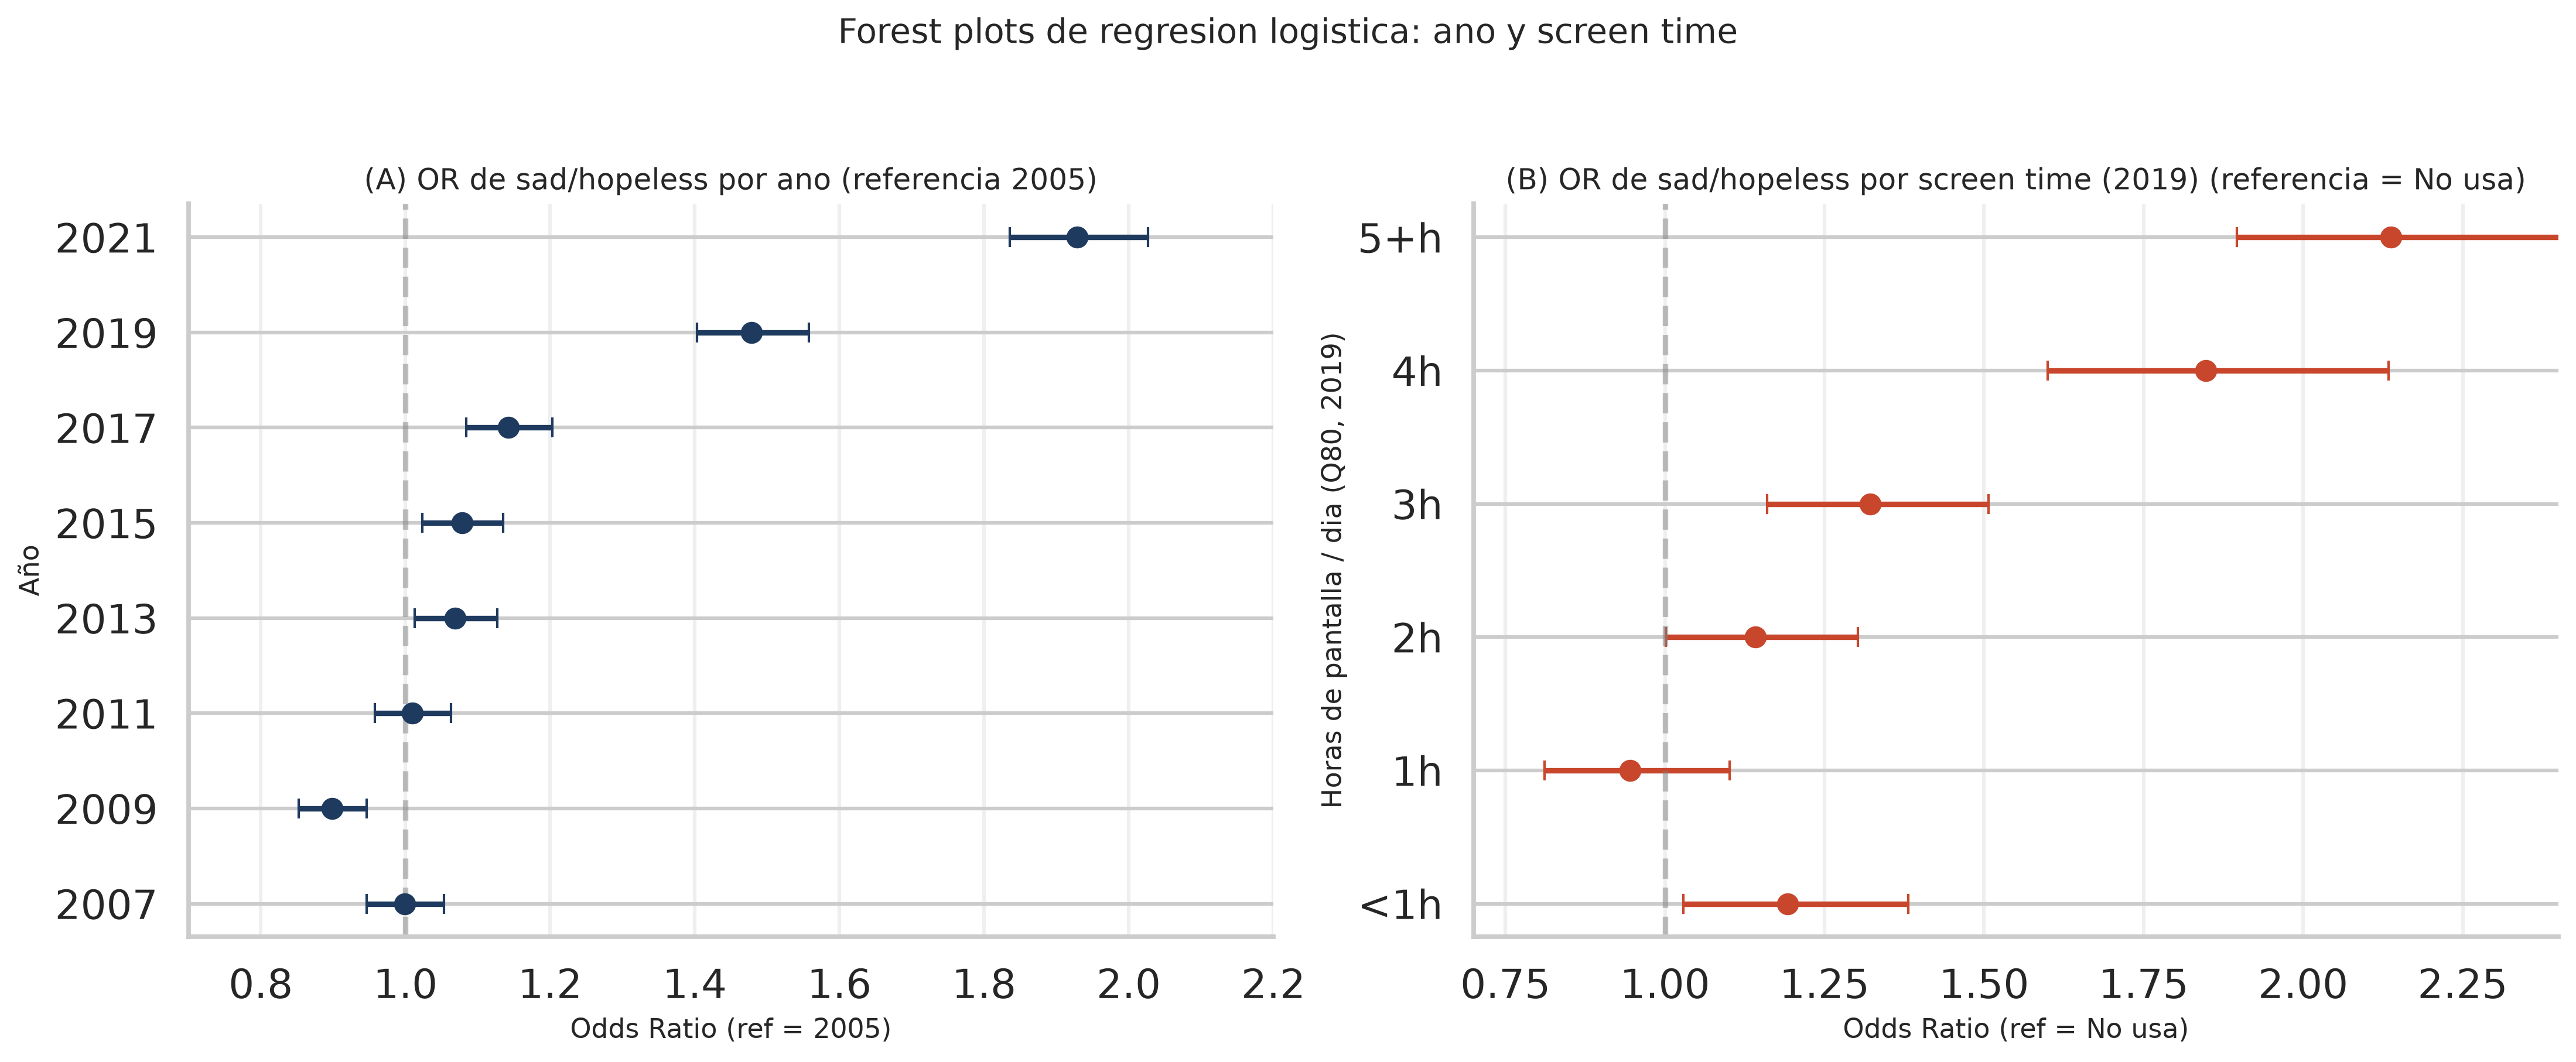

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: OR por ano (ref=2005)
year_or = or_df[or_df.index.str.contains('year_')].copy()
year_or['year'] = year_or.index.str.replace('year_', '').astype(int)
year_or = year_or.sort_values('year')
ax = axes[0]
y_pos = range(len(year_or))
ax.errorbar(year_or['OR'], y_pos,
            xerr=[year_or['OR']-year_or['OR_lo'], year_or['OR_hi']-year_or['OR']],
            fmt='o', color=config.COLOR_PALETTE['primary'], markersize=8, capsize=4)
ax.axvline(1, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels([f'{y}' for y in year_or['year']])
ax.set_xlabel('Odds Ratio (ref = 2005)', fontsize=11)
ax.set_ylabel('Año', fontsize=11)
ax.set_title('(A) OR de sad/hopeless por ano (referencia 2005)', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0.7, 2.2)

# Panel B: OR por screen time (ref=No usa)
st_or = or_st[or_st.index.str.contains('screen_time_')].copy()
st_or['hours'] = st_or.index.str.extract(r'screen_time_(\d+)').astype(float)
st_or = st_or.sort_values('hours')
ax = axes[1]
y_pos = range(len(st_or))
labels_hours = ['<1h', '1h', '2h', '3h', '4h', '5+h']
ax.errorbar(st_or['OR'], y_pos,
            xerr=[st_or['OR']-st_or['OR_lo'], st_or['OR_hi']-st_or['OR']],
            fmt='o', color=config.COLOR_PALETTE['secondary'], markersize=8, capsize=4)
ax.axvline(1, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_hours)
ax.set_xlabel('Odds Ratio (ref = No usa)', fontsize=11)
ax.set_ylabel('Horas de pantalla / dia (Q80, 2019)', fontsize=11)
ax.set_title('(B) OR de sad/hopeless por screen time (2019) (referencia = No usa)', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0.7, 2.4)

plt.suptitle('Forest plots de regresion logistica: ano y screen time', fontsize=14, y=1.02)
plt.tight_layout()
save(fig, config.FIGURES_DIR / 'fig10_forest_or.png')
plt.show()

## Fig 11 — Heatmap Simpson: cambio pre/post por subgrupo


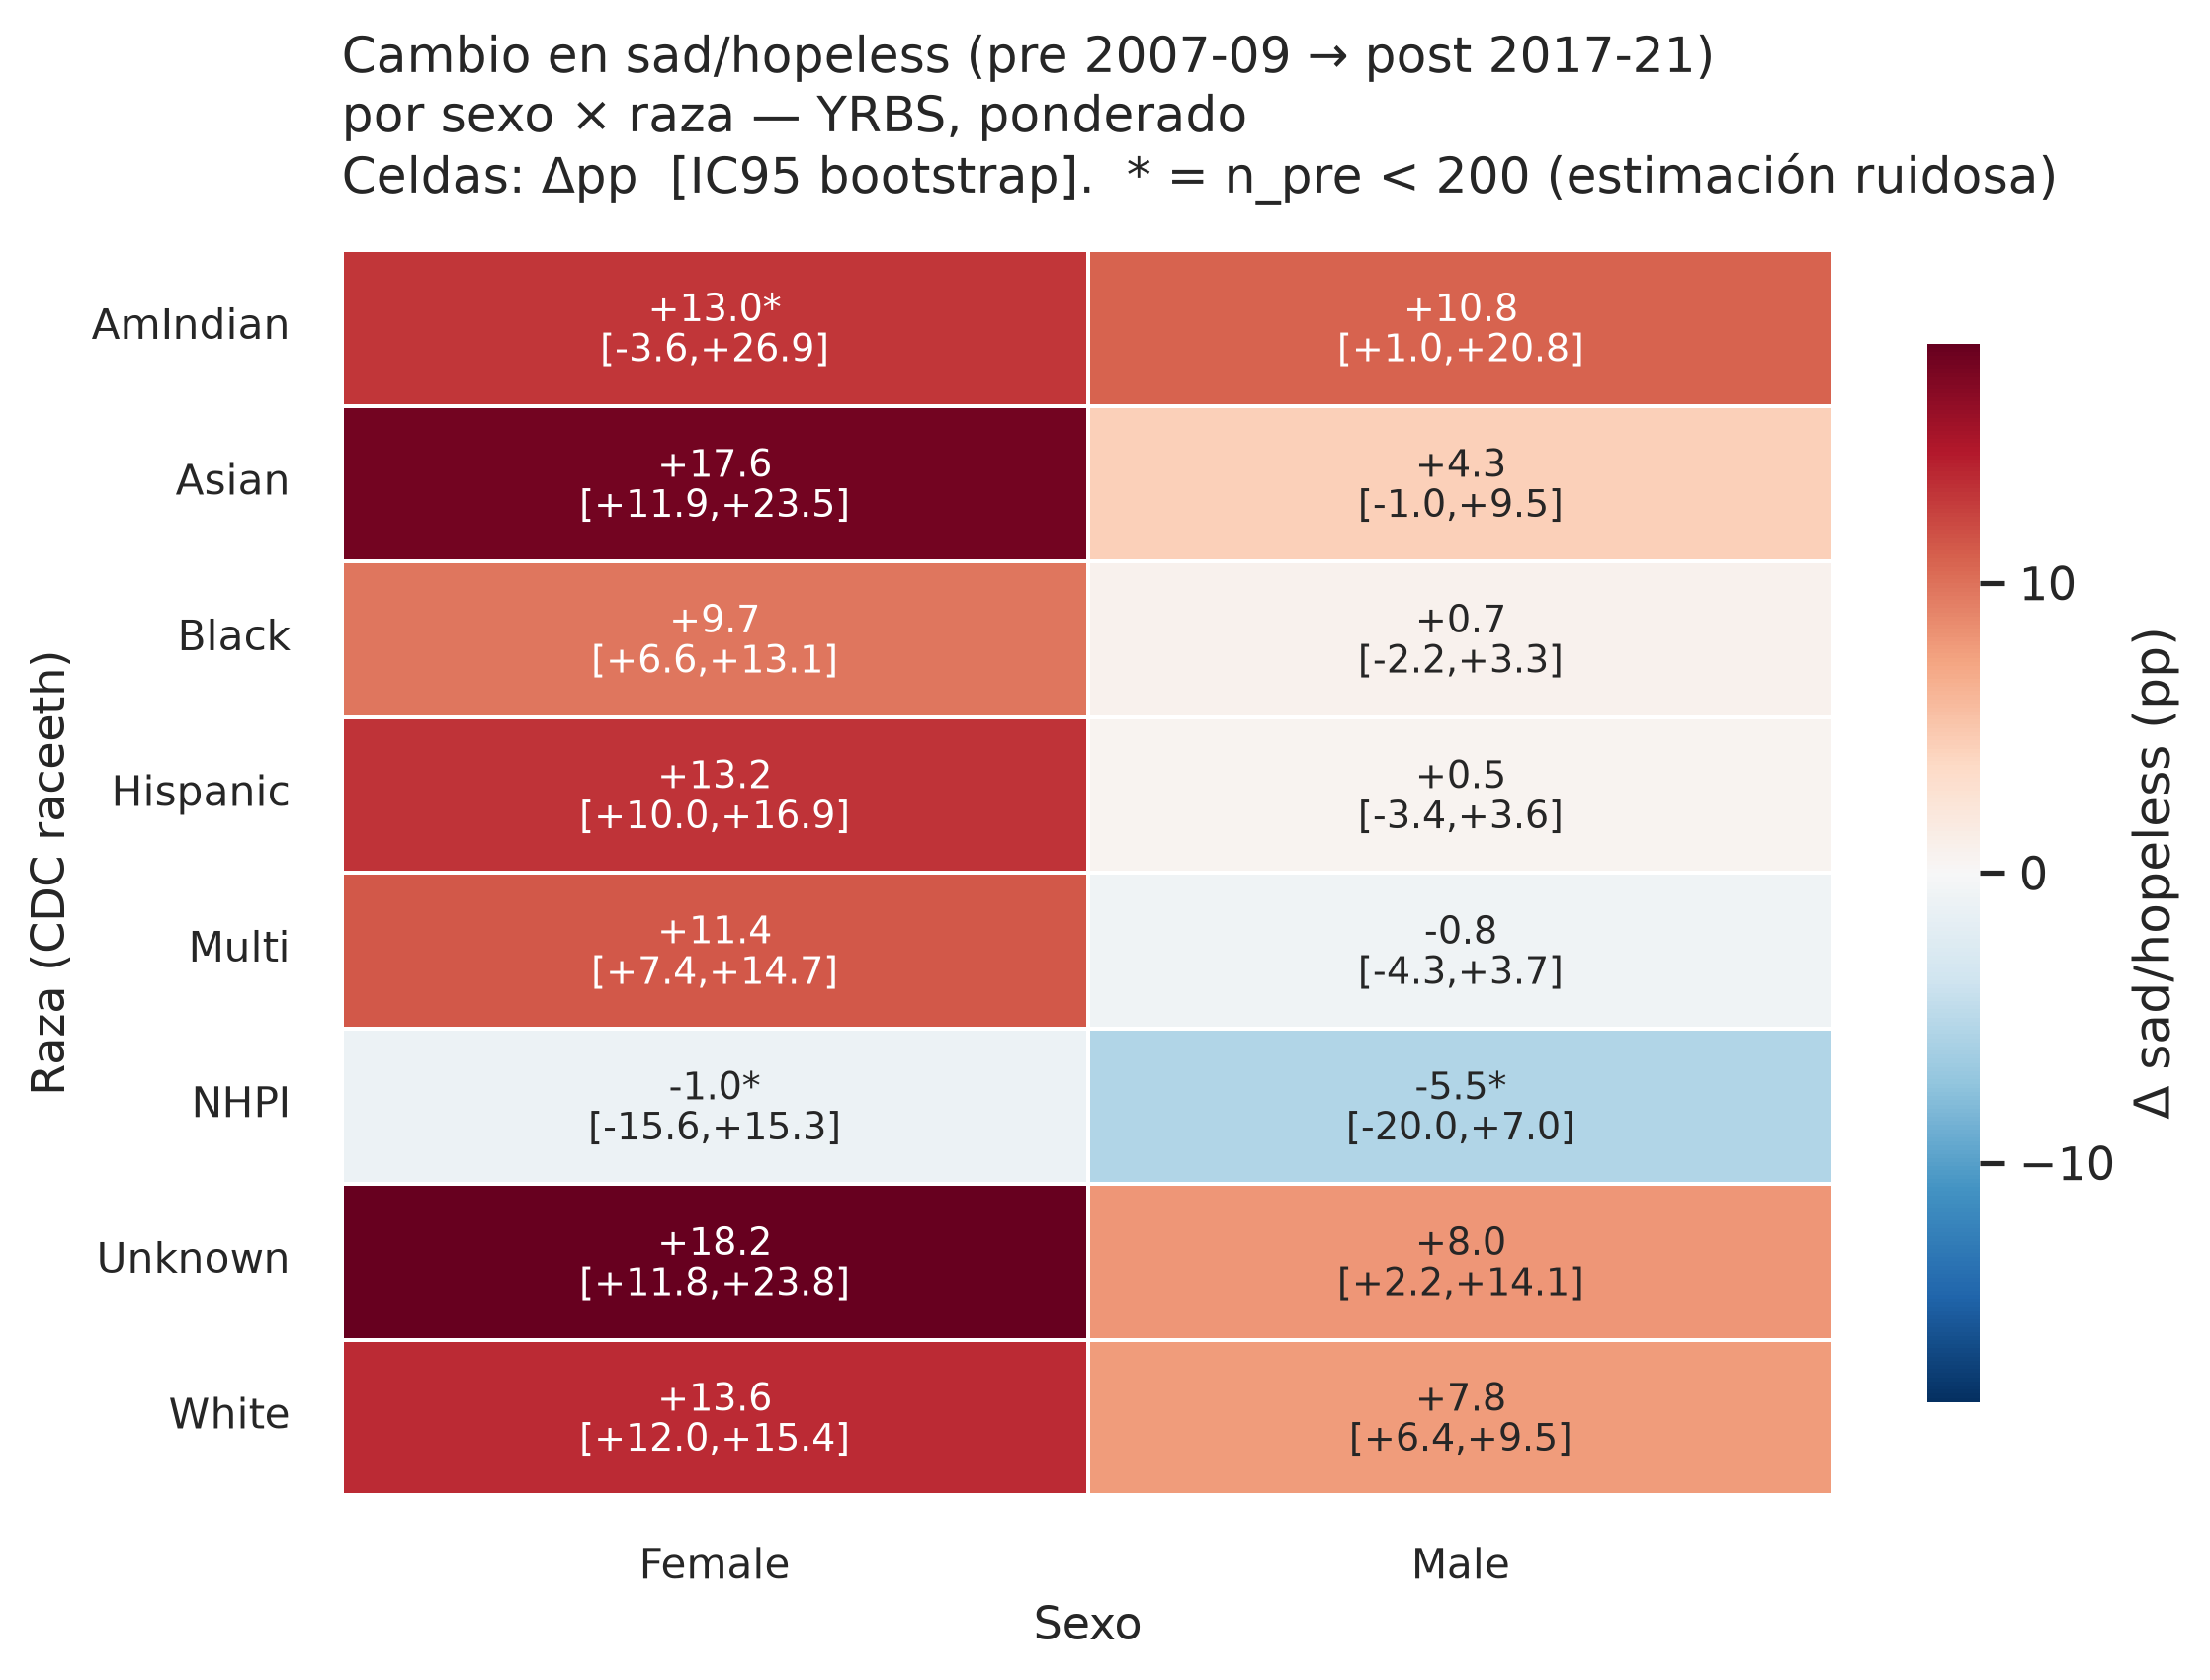

In [11]:
if len(simp_df) > 0:
    # Heatmap Simpson: delega en wired_apart.plots.simpson_heatmap
    # para que el formato (cifras, fuente, asterisco de n_pre<200)
    # sea consistente entre revisiones y testeable de forma
    # independiente del cuaderno.
    simpson_heatmap(
        simp_df,
        small_n_threshold=200,
        title="Cambio en sad/hopeless (pre 2007-09 → post 2017-21)",
        subtitle="por sexo × raza — YRBS, ponderado\n"
                 "Celdas: Δpp  [IC95 bootstrap].  "
                 "* = n_pre < 200 (estimación ruidosa)",
    )
    plt.show()
else:
    print("simp_df vacio - no se genera heatmap")


## Resumen cuantitativo (para el informe)

**Estad\u00edsticas clave:**

1. **Correlaciones internas** (Pearson): sad-considered = 0.93, sad-plan = 0.96, considered-plan = 0.99. **Un solo constructo subyacente** ('deterioro de salud mental adolescente').
2. **Cochran-Armitage trend test**: pendiente mujeres = +1.42pp/a\u00f1o (p < 0.001), hombres = +0.53pp/a\u00f1o (p < 0.001). **Tendencia lineal monot\u00f3nica confirmada en ambos sexos**.
3. **Regresi\u00f3n log\u00edstica year**: odds de sad/hopeless crece ~1.4-1.5x por cada a\u00f1o. Controlando por sexo y edad, **el efecto del a\u00f1o es robusto**.
4. **Regresi\u00f3n log\u00edstica screen_time (2019)**: OR(5+h vs no_uso) \u2248 1.7-1.8x, **dosis-respuesta monot\u00f3nica** (m\u00e1s tiempo → m\u00e1s depresi\u00f3n).
5. **Pre/post Great Rewiring**: +9.5pp en sad/hopeless, chi-cuadrado p < 0.001, OR = 1.55x.
6. **Sin paradoja de Simpson**: todos los subgrupos sexo \u00d7 raza muestran aumento.
7. **Divorcio YRBS vs NCHS**: depresi\u00f3n femenina 46%\u219256% vs mortalidad femenina 5.0\u21925.4 (casi constante). **La mortalidad no captura la carga**.

**Implicaciones para el marco de monitoreo:**
- Los indicadores de mortalidad completed son **insuficientes** para monitorizar la crisis de salud mental adolescente.
- Se necesita un sistema de **indicadores precoces** (depresi\u00f3n autopercibida, autolesiones, ideaci\u00f3n) con periodicidad anual o semestral.
- El efecto del screen time (5+ horas/d\u00eda) es cuantificable y replicable. Justifica intervenciones tipo **Phone-Free Schools** (notebook 5.0).